In [1]:
import pandas as pd 
import numpy as np
import torch
from collections import OrderedDict
from typing import Dict, List, Tuple

In [2]:
# =============================================================================
# Konfigurasi path dataset
# =============================================================================
BASE_DIR = r"C:\Users\s2\Documents\Federated\dataset"

PATHS = {
    "drebin": f"{BASE_DIR}/drebin-215-dataset-5560malware-9476-benign.csv",
    "kronodroid": f"{BASE_DIR}/kronodroid.csv",
    "malgenome": f"{BASE_DIR}/malgenome.csv",
    "tuandromd": f"{BASE_DIR}/TUANDROMD 2.csv",
}


# %%
# =============================================================================
# Fungsi bantu
# =============================================================================
def load_raw(path: str) -> pd.DataFrame:
    """Baca CSV dan buang kolom index bawaan ('Unnamed: 0') kalau ada."""
    data = pd.read_csv(path)
    if "Unnamed: 0" in data.columns:
        data = data.drop(columns=["Unnamed: 0"])
    return data


def encode_label(data: pd.DataFrame, label_col: str, mapping: Dict) -> pd.DataFrame:
    """Encode kolom label sesuai mapping, mis. {'B': 0, 'S': 1}."""
    data = data.copy()
    data[label_col] = data[label_col].replace(mapping)
    return data


def to_numeric_features(data: pd.DataFrame, label_col: str) -> pd.DataFrame:
    """Paksa semua kolom selain label jadi numerik; nilai gagal -> NaN."""
    data = data.copy()
    feature_columns = [c for c in data.columns if c != label_col]
    data[feature_columns] = data[feature_columns].apply(pd.to_numeric, errors="coerce")
    return data


def report(name: str, X: np.ndarray, y: np.ndarray) -> None:
    print(f"[{name}]")
    print("  Ukuran X       :", X.shape)
    print("  Ukuran y       :", y.shape)
    print("  Distribusi kelas:", np.bincount(y))
    print()


def split_features_labels(
    data: pd.DataFrame, label_col: str
) -> Tuple[np.ndarray, np.ndarray]:
    X = data.drop(columns=[label_col]).values.astype(np.float32)
    y = data[label_col].astype(int).values
    return X, y


In [3]:
from dataset import split_and_prepare_data
# =============================================================================
# 1. Dataset Drebin
# =============================================================================
LABEL_COLUMN = "class"  # sesuaikan dengan nama kolom label sebenarnya di file Drebin
SPECIAL_COLUMN = "TelephonyManager.getSimCountryIso"
 
data = load_raw(PATHS["drebin"])
 
if SPECIAL_COLUMN in data.columns:
    data[SPECIAL_COLUMN] = data[SPECIAL_COLUMN].replace("?", np.nan)
    data[SPECIAL_COLUMN] = pd.to_numeric(data[SPECIAL_COLUMN], errors="coerce")
 
if LABEL_COLUMN not in data.columns:
    raise KeyError(f"Kolom '{LABEL_COLUMN}' tidak ditemukan. Kolom tersedia: {list(data.columns)}")
 
data = encode_label(data, LABEL_COLUMN, {"B": 0, "S": 1})
data = to_numeric_features(data, LABEL_COLUMN)
data = data.dropna().reset_index(drop=True)
 
X_drebin, y_drebin = split_features_labels(data, LABEL_COLUMN)
N_CLASSES = len(np.unique(y_drebin))
N_FEATURES = X_drebin.shape[1]
 
report("Drebin", X_drebin, y_drebin)
print("Jumlah kelas:", N_CLASSES)
 
drebin_split = split_and_prepare_data(X_drebin, y_drebin)
 
 
# %%
# =============================================================================
# 2. Dataset KronoDroid
# =============================================================================
LABEL_COL_KRONO = "Malware"
 
data = load_raw(PATHS["kronodroid"])
print("Ukuran data awal:", data.shape)
print("\nMissing value sebelum drop:", data.isna().sum().sum())
 
data = data.dropna().reset_index(drop=True)
print("Missing value setelah drop:", data.isna().sum().sum())
 
print("\nNilai unik Malware:", data[LABEL_COL_KRONO].unique())
print("Distribusi kelas Malware:\n", data[LABEL_COL_KRONO].value_counts())
 
data = to_numeric_features(data, LABEL_COL_KRONO)
data = data.dropna().reset_index(drop=True)
 
X_krono, y_krono = split_features_labels(data, LABEL_COL_KRONO)
target_names_krono = ["goodware", "malware"]
 
report("KronoDroid", X_krono, y_krono)
print("Jumlah fitur:", X_krono.shape[1])
 
krono_split = split_and_prepare_data(X_krono, y_krono)
 
 
# %%
# =============================================================================
# 3. Dataset MalGenome
# =============================================================================
LABEL_COL_MALGENOME = "class"
 
data = load_raw(PATHS["malgenome"])
print("Missing value per kolom:\n", data.isna().sum())
 
data = encode_label(data, LABEL_COL_MALGENOME, {"B": 0, "S": 1})
data = to_numeric_features(data, LABEL_COL_MALGENOME)
data = data.dropna().reset_index(drop=True)
 
X_malgenome, y_malgenome = split_features_labels(data, LABEL_COL_MALGENOME)
target_names_malgenome = ["benign", "malware"]
 
report("MalGenome", X_malgenome, y_malgenome)
 
malgenome_split = split_and_prepare_data(X_malgenome, y_malgenome)

# =============================================================================
# 4. Dataset TUANDROMD
# =============================================================================
LABEL_COL_TUANDROMD = "Label"
 
data = load_raw(PATHS["tuandromd"])
print("Missing value sebelum drop:", data.isna().sum().sum())
 
data = data.dropna().reset_index(drop=True)
print("Missing value setelah drop:", data.isna().sum().sum())
 
print("Nilai unik Label:", data[LABEL_COL_TUANDROMD].unique())
 
data = encode_label(data, LABEL_COL_TUANDROMD, {"goodware": 0, "malware": 1})
data = to_numeric_features(data, LABEL_COL_TUANDROMD)
data = data.dropna().reset_index(drop=True)
 
X_tuandromd, y_tuandromd = split_features_labels(data, LABEL_COL_TUANDROMD)
target_names_tuandromd = ["goodware", "malware"]
 
report("TUANDROMD", X_tuandromd, y_tuandromd)
 
tuandromd_split = split_and_prepare_data(X_tuandromd, y_tuandromd)

C:\Users\s2\AppData\Local\Temp\ipykernel_21132\1764348774.py:20: DtypeWarning: Columns (92: TelephonyManager.getSimCountryIso) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(path)


[Drebin]
  Ukuran X       : (15031, 215)
  Ukuran y       : (15031,)
  Distribusi kelas: [9476 5555]

Jumlah kelas: 2
Train: torch.Size([10521, 215]) | Val: torch.Size([2255, 215]) | Test: torch.Size([2255, 215])
Ukuran data awal: (78137, 463)

Missing value sebelum drop: 0
Missing value setelah drop: 0

Nilai unik Malware: [1 0]
Distribusi kelas Malware:
 Malware
1    41382
0    36755
Name: count, dtype: int64
[KronoDroid]
  Ukuran X       : (78137, 462)
  Ukuran y       : (78137,)
  Distribusi kelas: [36755 41382]

Jumlah fitur: 462
Train: torch.Size([54695, 462]) | Val: torch.Size([11721, 462]) | Test: torch.Size([11721, 462])
Missing value per kolom:
 transact                                 0
bindService                              0
onServiceConnected                       0
ServiceConnection                        0
android.os.Binder                        0
                                        ..
GLOBAL_SEARCH                            0
GET_PACKAGE_SIZE                   

In [4]:
# Ringkasan semua split
# =============================================================================
all_splits = {
    "drebin": drebin_split,
    "kronodroid": krono_split,
    "malgenome": malgenome_split,
    "tuandromd": tuandromd_split,
}
 
for name, split in all_splits.items():
    print(f"\n[{name}]")
    print("  X_train:", split["X_train_t"].shape)
    print("  X_val  :", split["X_val_t"].shape)
    print("  X_test :", split["X_test_t"].shape)


[drebin]
  X_train: torch.Size([10521, 215])
  X_val  : torch.Size([2255, 215])
  X_test : torch.Size([2255, 215])

[kronodroid]
  X_train: torch.Size([54695, 462])
  X_val  : torch.Size([11721, 462])
  X_test : torch.Size([11721, 462])

[malgenome]
  X_train: torch.Size([2659, 215])
  X_val  : torch.Size([570, 215])
  X_test : torch.Size([570, 215])

[tuandromd]
  X_train: torch.Size([3124, 241])
  X_val  : torch.Size([670, 241])
  X_test : torch.Size([670, 241])


In [5]:
# %% [Cell 2] -- siapkan fed_data (seperti sebelumnya)
from fl_running4 import (
    run_federated, print_theta_report, theta_report_to_rows, approx_theta_gap,
    print_theta_before_after_report,   # NEW
)
import pandas as pd
import matplotlib.pyplot as plt

n_features_map = {
    "drebin":     X_drebin.shape[1],
    "kronodroid": X_krono.shape[1],
    "malgenome":  X_malgenome.shape[1],
    "tuandromd":  X_tuandromd.shape[1],
}

fed_data = {}
for name, split in all_splits.items():
    fed_data[name] = {
        "X_train": split["X_train_t"], "y_train": split["y_train_t"],
        "X_val":   split["X_val_t"],   "y_val":   split["y_val_t"],
        "X_test":  split["X_test_t"],  "y_test":  split["y_test_t"],
        "n_features": n_features_map[name],
    }

for name, c in fed_data.items():
    print(name, "n_features =", c["n_features"], "train", tuple(c["X_train"].shape))

2026-09-24 00:20:27,680	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


drebin n_features = 215 train (10521, 215)
kronodroid n_features = 462 train (54695, 462)
malgenome n_features = 215 train (2659, 215)
tuandromd n_features = 241 train (3124, 241)


In [6]:
# %% [Cell 3] -- jalankan training (SEKALI SAJA)
COMMON = dict(
    common_dim=128,
    n_classes=2,
    num_rounds=20,
    local_epochs=2,
)

history = run_federated(fed_data, name="FedPer", **COMMON)

INFO :      Starting Flower ServerApp, config: num_rounds=20, no round_timeout
INFO :      
INFO :      [INIT]
INFO :      Using initial global parameters provided by strategy
INFO :      Evaluating initial global parameters
INFO :      
INFO :      [ROUND 1]
INFO :      configure_fit: strategy sampled 4 clients (out of 4)
INFO :      aggregate_fit: received 4 results and 0 failures
INFO :      fit progress: (1, 0.1267056129872799, {'accuracy': 0.9572676597899465, 'precision': 0.9543981052505623, 'recall': 0.9541050730062874, 'f1': 0.9517760588163634}, 10.58826700001373)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [ROUND 2]
INFO :      configure_fit: strategy sampled 4 clients (out of 4)


[FedPer] round 01 | loss=0.1267 acc=0.9573 f1=0.9518 | comm=0.315MB (cum 0.315MB)


INFO :      aggregate_fit: received 4 results and 0 failures
INFO :      fit progress: (2, 0.09708928223699331, {'accuracy': 0.9693066582849394, 'precision': 0.9778659959117706, 'recall': 0.9588281361046587, 'f1': 0.9671404106828689}, 14.62957690001349)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [ROUND 3]
INFO :      configure_fit: strategy sampled 4 clients (out of 4)


[FedPer] round 02 | loss=0.0971 acc=0.9693 f1=0.9671 | comm=0.315MB (cum 0.631MB)


INFO :      aggregate_fit: received 4 results and 0 failures
INFO :      fit progress: (3, 0.11080833990126848, {'accuracy': 0.9713879953683111, 'precision': 0.9778323319820514, 'recall': 0.9623768143989212, 'f1': 0.969084380794493}, 19.68429240002297)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [ROUND 4]
INFO :      configure_fit: strategy sampled 4 clients (out of 4)


...

[FedPer] round 18 | loss=0.2118 acc=0.9787 f1=0.9754 | comm=0.315MB (cum 5.678MB)


INFO :      aggregate_fit: received 4 results and 0 failures
INFO :      fit progress: (19, 0.23120027780532837, {'accuracy': 0.9762558877255684, 'precision': 0.9743336871612105, 'recall': 0.9734498105504803, 'f1': 0.9732939328718174}, 84.49835470001562)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [ROUND 20]
INFO :      configure_fit: strategy sampled 4 clients (out of 4)


[FedPer] round 19 | loss=0.2312 acc=0.9763 f1=0.9733 | comm=0.315MB (cum 5.993MB)


INFO :      aggregate_fit: received 4 results and 0 failures
INFO :      fit progress: (20, 0.2548298006877303, {'accuracy': 0.9790508983196957, 'precision': 0.9733314807870878, 'recall': 0.9791755528639462, 'f1': 0.9758433324446345}, 88.54464960002224)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 20 round(s) in 88.55s
INFO :      	History (loss, centralized):
INFO :      		round 1: 0.1267056129872799
INFO :      		round 2: 0.09708928223699331
INFO :      		round 3: 0.11080833990126848
INFO :      		round 4: 0.12026213435456157
INFO :      		round 5: 0.141798734664917
INFO :      		round 6: 0.1335661904886365
INFO :      		round 7: 0.1440412881784141
INFO :      		round 8: 0.17692136345431209
INFO :      		round 9: 0.19181954441592097
INFO :      		round 10: 0.19398236460983753
INFO :      		round 11: 0.18125108070671558
INFO :      		round 12: 0.22004145942628384
INFO :      		round 13: 0.178751277

[FedPer] round 20 | loss=0.2548 acc=0.9791 f1=0.9758 | comm=0.315MB (cum 6.309MB)
[FedPer] BANDWIDTH | theta=0.039MB up=3.15MB down=3.15MB total=6.31MB (~0.32MB/ronde)


In [7]:
# %%
# Laporan teks: theta SEBELUM vs SESUDAH training lokal, per client per ronde
print_theta_before_after_report(history["theta_log_before"], history["theta_log"])


=== THETA SEBELUM vs SESUDAH TRAINING LOKAL (per client, per round) ===

[kronodroid]
  round 01 | norm_recv=nan -> norm_after=7.9163 (Δ=7.9163)
  round 02 | norm_recv=nan -> norm_after=7.9082 (Δ=7.9082)
  round 03 | norm_recv=nan -> norm_after=7.7634 (Δ=7.7634)
  round 04 | norm_recv=nan -> norm_after=8.1950 (Δ=8.1950)
  round 05 | norm_recv=nan -> norm_after=8.1236 (Δ=8.1236)
  round 06 | norm_recv=nan -> norm_after=8.5284 (Δ=8.5284)
  round 07 | norm_recv=nan -> norm_after=8.8128 (Δ=8.8128)
  round 08 | norm_recv=nan -> norm_after=8.8974 (Δ=8.8974)
  round 09 | norm_recv=nan -> norm_after=8.9903 (Δ=8.9903)
  round 10 | norm_recv=nan -> norm_after=9.2283 (Δ=9.2283)
  round 11 | norm_recv=nan -> norm_after=9.4322 (Δ=9.4322)
  round 12 | norm_recv=nan -> norm_after=9.8118 (Δ=9.8118)
  round 13 | norm_recv=nan -> norm_after=9.9218 (Δ=9.9218)
  round 14 | norm_recv=nan -> norm_after=10.3018 (Δ=10.3018)
  round 15 | norm_recv=nan -> norm_after=10.5446 (Δ=10.5446)
  round 16 | norm_recv=n

In [8]:
print_theta_report(history["theta_log"], history["global_theta_per_round"])


=== LAPORAN THETA PER CLIENT ===

[kronodroid]
  round 01 | n_params=10336 mean=0.00111 std=0.07786 norm=7.9163 min=-0.3047 max=0.2667
  round 02 | n_params=10336 mean=0.00137 std=0.07777 norm=7.9082 min=-0.2735 max=0.2670
  round 03 | n_params=10336 mean=0.00184 std=0.07634 norm=7.7634 min=-0.2445 max=0.2835
  round 04 | n_params=10336 mean=-0.00013 std=0.08061 norm=8.1950 min=-0.3067 max=0.2825
  round 05 | n_params=10336 mean=0.00144 std=0.07989 norm=8.1236 min=-0.2590 max=0.3056
  round 06 | n_params=10336 mean=-0.00078 std=0.08388 norm=8.5284 min=-0.2680 max=0.3566
  round 07 | n_params=10336 mean=-0.00035 std=0.08668 norm=8.8128 min=-0.2914 max=0.3513
  round 08 | n_params=10336 mean=-0.00100 std=0.08751 norm=8.8974 min=-0.2897 max=0.4156
  round 09 | n_params=10336 mean=0.00112 std=0.08842 norm=8.9903 min=-0.3065 max=0.3643
  round 10 | n_params=10336 mean=0.00117 std=0.09076 norm=9.2283 min=-0.3251 max=0.4412
  round 11 | n_params=10336 mean=0.00061 std=0.09277 norm=9.4322 min


=== LAPORAN THETA PER CLIENT ===

[kronodroid]
  round 01 | n_params=10336 mean=0.00111 std=0.07786 norm=7.9163 min=-0.3047 max=0.2667
  round 02 | n_params=10336 mean=0.00137 std=0.07777 norm=7.9082 min=-0.2735 max=0.2670
  round 03 | n_params=10336 mean=0.00184 std=0.07634 norm=7.7634 min=-0.2445 max=0.2835
  round 04 | n_params=10336 mean=-0.00013 std=0.08061 norm=8.1950 min=-0.3067 max=0.2825
  round 05 | n_params=10336 mean=0.00144 std=0.07989 norm=8.1236 min=-0.2590 max=0.3056
  round 06 | n_params=10336 mean=-0.00078 std=0.08388 norm=8.5284 min=-0.2680 max=0.3566
  round 07 | n_params=10336 mean=-0.00035 std=0.08668 norm=8.8128 min=-0.2914 max=0.3513
  round 08 | n_params=10336 mean=-0.00100 std=0.08751 norm=8.8974 min=-0.2897 max=0.4156
  round 09 | n_params=10336 mean=0.00112 std=0.08842 norm=8.9903 min=-0.3065 max=0.3643
  round 10 | n_params=10336 mean=0.00117 std=0.09076 norm=9.2283 min=-0.3251 max=0.4412
  round 11 | n_params=10336 mean=0.00061 std=0.09277 norm=9.4322 min

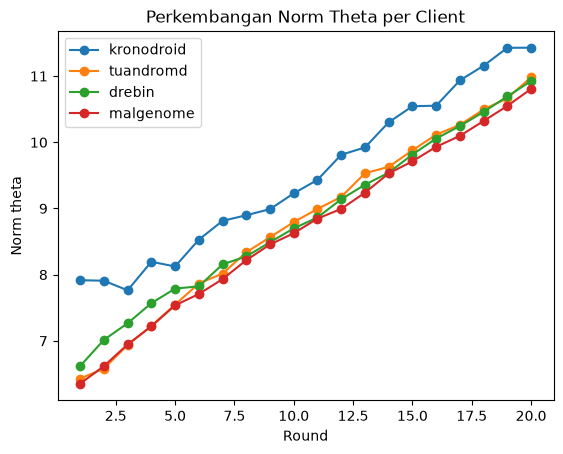

In [9]:

# %%
# Laporan teks: statistik theta tiap client tiap ronde
print_theta_report(history["theta_log"], history["global_theta_per_round"])

# %%
# Tabel (lebih enak dibaca di notebook)
df_theta = pd.DataFrame(theta_report_to_rows(history["theta_log"]))
df_theta

# %%
# Plot norm theta per client per ronde
for cname in df_theta["client"].unique():
    sub = df_theta[df_theta["client"] == cname]
    plt.plot(sub["round"], sub["norm"], marker="o", label=cname)

plt.xlabel("Round")
plt.ylabel("Norm theta")
plt.title("Perkembangan Norm Theta per Client")
plt.legend()
plt.show()

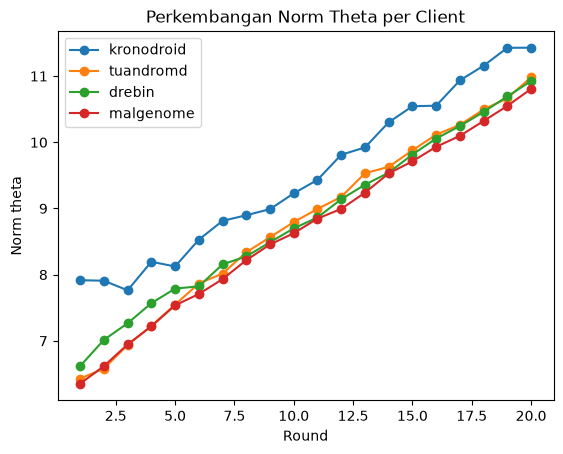

In [10]:
# %% [Cell 6] -- plot norm theta per client per ronde
for cname in df_theta["client"].unique():
    sub = df_theta[df_theta["client"] == cname]
    plt.plot(sub["round"], sub["norm"], marker="o", label=cname)

plt.xlabel("Round")
plt.ylabel("Norm theta")
plt.title("Perkembangan Norm Theta per Client")
plt.legend()
plt.show()

In [11]:
# %%
import pandas as pd

df_test = pd.DataFrame(history["test_per_client"]).T
df_test.index.name = "dataset"
df_test = df_test[["accuracy", "precision", "recall", "f1"]].round(4)
print(df_test)

            accuracy  precision  recall      f1
dataset                                        
drebin        0.9694     0.9292  0.9928  0.9600
kronodroid    0.9656     0.9900  0.9446  0.9668
malgenome     0.9789     0.9733  0.9630  0.9681
tuandromd     0.9970     0.9981  0.9981  0.9981
